In [1]:
# 1. Data Handling
import pandas as pd
import numpy as np
import os

# 2. Visualization
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")


# 3. Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# 4. Model Training
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# 5. Model Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# 6. Model Saving
import joblib

import warnings

# Hide all warnings
warnings.filterwarnings("ignore")


In [2]:
# Load the dataset
df = pd.read_csv("customer_churn_data.csv")


In [3]:
# 1. First 5 rows
print("First 5 Rows:")
(df.head())

First 5 Rows:


,customer_id,age,gender,region,tenure_months,monthly_charges,total_charges,contract_type,internet_service,tech_support,online_security,paperless_billing,payment_method,num_support_calls,late_payments_last_year,avg_monthly_usage_gb,churn
0,CUST10001,23,Female,East,45,65.65,2659.64,Two year,DSL,Yes,Yes,No,Electronic check,1,1,141.4,No
1,CUST10002,66,Male,East,43,105.10,4357.87,One year,Fiber optic,No,Yes,Yes,Electronic check,1,1,345.3,No
2,CUST10003,59,Female,West,16,61.12,1074.50,Month-to-month,DSL,No,Yes,Yes,Electronic check,1,1,160.2,Yes
3,CUST10004,45,Female,East,58,89.25,4973.26,One year,Fiber optic,Yes,Yes,Yes,Electronic check,3,1,461.5,No
4,CUST10005,45,Female,North,50,91.11,4580.38,Month-to-month,Fiber optic,Yes,Yes,Yes,Bank transfer,0,3,470.1,Yes


In [4]:
# 2. Last 5 rows
print("\nLast 5 Rows:")
(df.tail())


Last 5 Rows:


,customer_id,age,gender,region,tenure_months,monthly_charges,total_charges,contract_type,internet_service,tech_support,online_security,paperless_billing,payment_method,num_support_calls,late_payments_last_year,avg_monthly_usage_gb,churn
1215,CUST10722,76,Female,South,48,61.37,2896.21,Month-to-month,DSL,Yes,Yes,Yes,Electronic check,1,1,93.5,Yes
1216,CUST11129,53,Male,East,9,86.36,716.92,One year,Fiber optic,Yes,Yes,Yes,NaN,0,2,387.3,No
1217,CUST10400,37,Female,South,69,78.02,5132.74,One year,Fiber optic,No,Yes,Yes,Bank transfer,1,1,387.6,No
1218,CUST10695,23,Male,South,56,84.87,4533.03,One year,Fiber optic,No,No,No,Bank transfer,2,3,304.3,No
1219,CUST10110,62,Female,West,45,89.86,3730.49,Two year,Fiber optic,No,Yes,Yes,Electronic check,0,4,308.0,No


In [5]:
# 3. Number of rows and columns
print("\nNumber of Rows and Columns:")
print(df.shape)


Number of Rows and Columns:
(1220, 17)


In [6]:
# 4. Column names
print("\nColumn Names:")
print(df.columns.tolist())


Column Names:
['customer_id', 'age', 'gender', 'region', 'tenure_months', 'monthly_charges', 'total_charges', 'contract_type', 'internet_service', 'tech_support', 'online_security', 'paperless_billing', 'payment_method', 'num_support_calls', 'late_payments_last_year', 'avg_monthly_usage_gb', 'churn']


In [7]:
# 5. Data types
print("\nData Types:")
print(df.dtypes)


Data Types:
customer_id                    str
age                          int64
gender                         str
region                         str
tenure_months                int64
monthly_charges            float64
total_charges              float64
contract_type                  str
internet_service               str
tech_support                   str
online_security                str
paperless_billing              str
payment_method                 str
num_support_calls            int64
late_payments_last_year      int64
avg_monthly_usage_gb       float64
churn                          str
dtype: object


In [8]:
# 6. Dataset information
print("\nDataset Information:")
df.info()


Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 1220 entries, 0 to 1219
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customer_id              1220 non-null   str    
 1   age                      1220 non-null   int64  
 2   gender                   1220 non-null   str    
 3   region                   1220 non-null   str    
 4   tenure_months            1220 non-null   int64  
 5   monthly_charges          1198 non-null   float64
 6   total_charges            1187 non-null   float64
 7   contract_type            1220 non-null   str    
 8   internet_service         1220 non-null   str    
 9   tech_support             1194 non-null   str    
 10  online_security          1199 non-null   str    
 11  paperless_billing        1220 non-null   str    
 12  payment_method           1200 non-null   str    
 13  num_support_calls        1220 non-null   int64  
 14  late_payments

In [9]:
# 7. Descriptive statistics
print("\nDescriptive Statistics:")
print(df.describe())


Descriptive Statistics:
               age  tenure_months  monthly_charges  total_charges  \
count  1220.000000    1220.000000      1198.000000    1187.000000   
mean     49.309016      36.956557        66.509474    2421.133437   
std      18.125678      20.512560        24.295211    1681.896803   
min      18.000000       1.000000        18.000000      12.600000   
25%      34.000000      19.000000        50.047500    1011.740000   
50%      49.500000      38.000000        69.020000    2120.450000   
75%      65.000000      55.000000        86.465000    3619.765000   
max      80.000000      72.000000       118.580000    7579.280000   

       num_support_calls  late_payments_last_year  avg_monthly_usage_gb  
count        1220.000000              1220.000000           1196.000000  
mean            1.759836                 1.143443            214.370569  
std             1.298902                 1.078501            143.970148  
min             0.000000                 0.000000        

# 3. Data Quality Checks

In [10]:
# 1. Missing values in every column
print("Missing Values in Every Column:")
print(df.isnull().sum())

Missing Values in Every Column:
customer_id                 0
age                         0
gender                      0
region                      0
tenure_months               0
monthly_charges            22
total_charges              33
contract_type               0
internet_service            0
tech_support               26
online_security            21
paperless_billing           0
payment_method             20
num_support_calls           0
late_payments_last_year     0
avg_monthly_usage_gb       24
churn                       0
dtype: int64


In [11]:
# 2. Duplicate records
print("\nNumber of Duplicate Records:")
print(df.duplicated().sum())


Number of Duplicate Records:
20


In [12]:
# 3. Unique values in categorical columns
print("\nUnique Values in Categorical Columns:")

categorical_columns = df.select_dtypes(include="object").columns

for column in categorical_columns:
    print(f"\n{column}:")
    print(df[column].unique())


Unique Values in Categorical Columns:

customer_id:
<ArrowStringArray>
['CUST10001', 'CUST10002', 'CUST10003', 'CUST10004', 'CUST10005', 'CUST10006',
 'CUST10007', 'CUST10008', 'CUST10009', 'CUST10010',
 ...
 'CUST11191', 'CUST11192', 'CUST11193', 'CUST11194', 'CUST11195', 'CUST11196',
 'CUST11197', 'CUST11198', 'CUST11199', 'CUST11200']
Length: 1200, dtype: str

gender:
<ArrowStringArray>
['Female', 'Male']
Length: 2, dtype: str

region:
<ArrowStringArray>
['East', 'West', 'North', 'South']
Length: 4, dtype: str

contract_type:
<ArrowStringArray>
['Two year', 'One year', 'Month-to-month']
Length: 3, dtype: str

internet_service:
<ArrowStringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str

tech_support:
<ArrowStringArray>
['Yes', 'No', 'No internet service', nan]
Length: 4, dtype: str

online_security:
<ArrowStringArray>
['Yes', 'No', 'No internet service', nan]
Length: 4, dtype: str

paperless_billing:
<ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str

payment_method:


In [13]:
# 4. Class distribution of the Churn target
print("\nChurn Class Distribution:")
print(df["churn"].value_counts())


Churn Class Distribution:
churn
Yes    688
No     532
Name: count, dtype: int64


In [14]:
# 5. Churn class distribution in percentage
print("\nChurn Class Distribution (%):")
print(df["churn"].value_counts(normalize=True) * 100)


Churn Class Distribution (%):
churn
Yes    56.393443
No     43.606557
Name: proportion, dtype: float64


## 4. Data Cleaning Wording

### Duplicate Records
Duplicate records will be removed because they represent repeated entries and can negatively affect the model's performance.

### Missing Numeric Values
Missing values in numerical columns will be replaced with the median value. Median is preferred because it is less affected by extreme values or outliers.

### Missing Categorical Values
Missing values in categorical columns will be replaced with the mode (most frequent value), as this preserves the existing category distribution.

### Customer ID
`customer_id` will be removed from model training because it is only an identifier and does not provide meaningful information for predicting customer churn.

# 4. Data Cleaning


In [15]:
# Make a copy of the original dataset
df_clean = df.copy()

In [16]:
# 1. Remove duplicate records
df_clean = df_clean.drop_duplicates()

In [17]:
# 2. Identify numeric and categorical columns
numeric_columns = df_clean.select_dtypes(include=np.number).columns
categorical_columns = df_clean.select_dtypes(include="object").columns

In [18]:
# 3. Handle missing numeric values using median
for column in numeric_columns:
    df_clean[column] = df_clean[column].fillna(df_clean[column].median())

In [19]:
# 4. Handle missing categorical values using mode
for column in categorical_columns:
    if df_clean[column].isnull().sum() > 0:
        df_clean[column] = df_clean[column].fillna(df_clean[column].mode()[0])

In [20]:
# 5. Remove customer_id from model training
if "customer_id" in df_clean.columns:
    df_clean = df_clean.drop("customer_id", axis=1)

In [21]:
# Display cleaned dataset
print("Cleaned Dataset:")
(df_clean.head())
df_clean.to_csv("cleaned_customer_churn.csv", index=False)

print("Cleaned dataset saved successfully!")
print("File name: cleaned_customer_churn.csv")




Cleaned Dataset:
Cleaned dataset saved successfully!
File name: cleaned_customer_churn.csv


In [22]:
# Check remaining missing values
print("\nRemaining Missing Values:")
print(df_clean.isnull().sum())


Remaining Missing Values:
age                        0
gender                     0
region                     0
tenure_months              0
monthly_charges            0
total_charges              0
contract_type              0
internet_service           0
tech_support               0
online_security            0
paperless_billing          0
payment_method             0
num_support_calls          0
late_payments_last_year    0
avg_monthly_usage_gb       0
churn                      0
dtype: int64


In [23]:
# Check remaining duplicates
print("\nRemaining Duplicate Records:")
print(df_clean.duplicated().sum())


Remaining Duplicate Records:
0


# 5. Exploratory Data Analysis


# 1. Churn Class Distribution


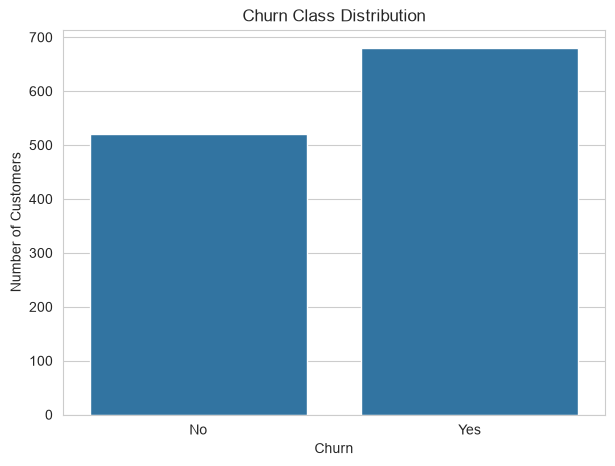

In [24]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df_clean, x="churn")

plt.title("Churn Class Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

### Observation
- The chart shows the distribution of customers who churned and those who did not churn.
- If the two classes have noticeably different sizes, the dataset is imbalanced and this should be considered during model evaluation.

# 2. Churn by Contract Type


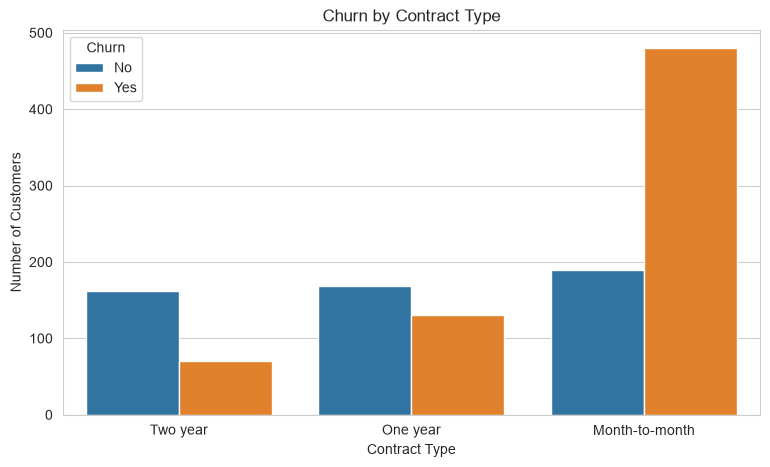

In [25]:
plt.figure(figsize=(9, 5))

sns.countplot(
    data=df_clean,
    x="contract_type",
    hue="churn"
)

plt.title("Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.legend(title="Churn")

plt.show()

### Observation
- Customers with shorter-term contracts generally show higher churn compared with customers on longer-term contracts.
- Long-term contracts appear to be associated with better customer retention.

# 3. Churn by Internet Service


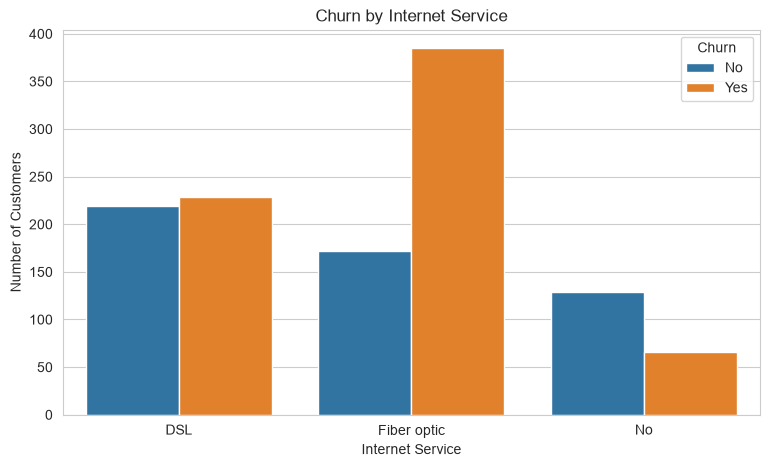

In [26]:
plt.figure(figsize=(9, 5))

sns.countplot(
    data=df_clean,
    x="internet_service",
    hue="churn"
)

plt.title("Churn by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")
plt.legend(title="Churn")

plt.show()

### Observation
- Churn levels differ across internet service types.
- Customers using certain internet services show a higher proportion of churn, indicating that internet service type may be an important predictor.

# 4. Monthly Charges Distribution


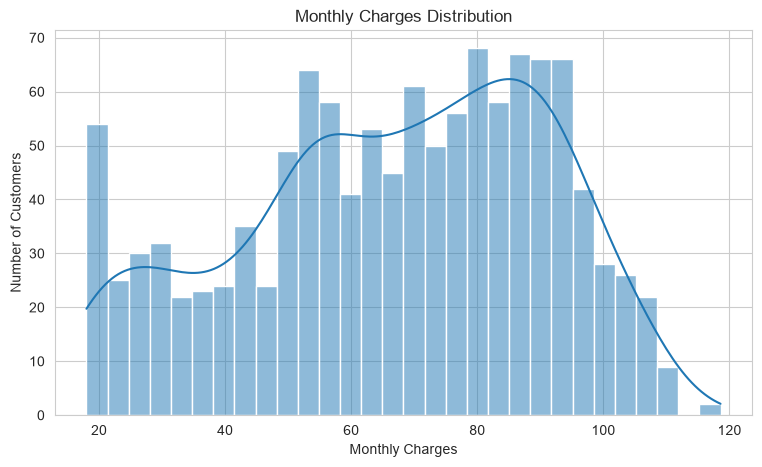

In [27]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=df_clean,
    x="monthly_charges",
    bins=30,
    kde=True
)

plt.title("Monthly Charges Distribution")
plt.xlabel("Monthly Charges")
plt.ylabel("Number of Customers")

plt.show()

### Observation
- Monthly charges are distributed across a range of values, with most customers concentrated around the common charge levels.
- The distribution helps identify whether very high or very low monthly charges are present in the dataset.

# 5. Tenure Distribution


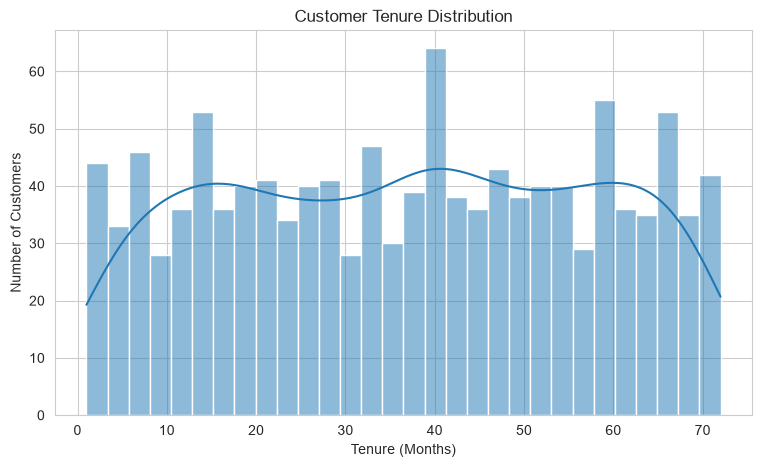

In [28]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=df_clean,
    x="tenure_months",
    bins=30,
    kde=True
)

plt.title("Customer Tenure Distribution")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")

plt.show()

### Observation
- The chart shows how long customers have stayed with the company.
- Customers are distributed across different tenure periods, allowing us to investigate whether shorter-tenure customers are more likely to churn.

# 6. Additional Visualization — Churn vs Monthly Charges

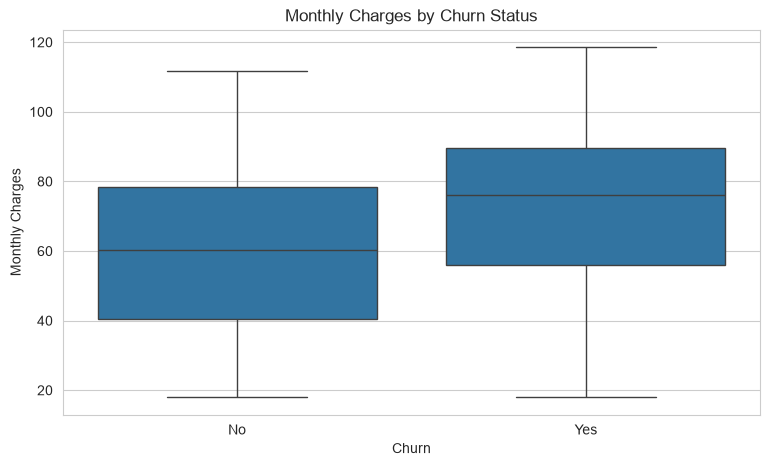

In [29]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df_clean,
    x="churn",
    y="monthly_charges"
)

plt.title("Monthly Charges by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()

### Observation
- The boxplot compares monthly charges between customers who churned and those who did not.
- Differences in the median and spread of monthly charges can indicate whether pricing is related to customer churn.

# 6. Prepare Features and Target

In [30]:
# Target variable
y = df_clean["churn"]

# Input features
X = df_clean.drop("churn", axis=1)

# Identify numeric columns
numeric_columns = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

# Identify categorical columns
categorical_columns = X.select_dtypes(include=["object", "category"]).columns.tolist()

# Display results
print("Input Features (X):")
print(X.head())

print("\nTarget Variable (y):")
print(y.head())

print("\nNumeric Columns:")
print(numeric_columns)

print("\nCategorical Columns:")
print(categorical_columns)

Input Features (X):
   age  gender region  tenure_months  monthly_charges  total_charges  \
0   23  Female   East             45            65.65        2659.64   
1   66    Male   East             43           105.10        4357.87   
2   59  Female   West             16            61.12        1074.50   
3   45  Female   East             58            89.25        4973.26   
4   45  Female  North             50            91.11        4580.38   

    contract_type internet_service tech_support online_security  \
0        Two year              DSL          Yes             Yes   
1        One year      Fiber optic           No             Yes   
2  Month-to-month              DSL           No             Yes   
3        One year      Fiber optic          Yes             Yes   
4  Month-to-month      Fiber optic          Yes             Yes   

  paperless_billing    payment_method  num_support_calls  \
0                No  Electronic check                  1   
1               Yes  Ele

## 7. Train-Test Split

The cleaned dataset is divided into training and testing sets.

- **80%** of the data is used for training the model.
- **20%** of the data is used for testing the model.
- A fixed `random_state=42` is used to make the split reproducible.

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

## 8. Preprocessing

A preprocessing pipeline is created to prepare both numerical and categorical features.

- Missing numerical values are replaced with the median.
- Missing categorical values are replaced with the most frequent value.
- Categorical variables are converted into numerical values using One-Hot Encoding.
- Numerical features are scaled using StandardScaler.
- ColumnTransformer is used to apply different preprocessing steps to numerical and categorical columns.
- The preprocessing is included in a Scikit-Learn Pipeline to prevent data leakage and keep the preprocessing consistent during training and testing.

In [32]:
# ============================================
# 8. Preprocessing
# ============================================

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Numerical preprocessing
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical preprocessing
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Combine both preprocessing methods
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_columns),
        ("cat", categorical_transformer, categorical_columns)
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


## 9. Train At Least TWO Models

Two classification algorithms are trained and compared:

1. Logistic Regression
2. Random Forest Classifier

Both models use the same preprocessing pipeline so that the numerical and categorical features are handled consistently.

Logistic Regression provides a simple baseline classification model, while Random Forest can capture more complex relationships between customer features and churn.

# 9. Model 1 - Logistic Regression


In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

logistic_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

# Train the model
logistic_model.fit(X_train, y_train)

print("Logistic Regression trained successfully.")

Logistic Regression trained successfully.


# Model 2 - Random Forest


In [34]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])

# Train the model
random_forest_model.fit(X_train, y_train)

print("Random Forest trained successfully.")

Random Forest trained successfully.


# Generate Predictions


In [35]:


# Logistic Regression predictions
y_pred_logistic = logistic_model.predict(X_test)

# Random Forest predictions
y_pred_rf = random_forest_model.predict(X_test)

print("Predictions generated successfully.")

Predictions generated successfully.


In [36]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
import pandas as pd

# Dictionary to store model results
results = {}

# List of trained models
models = {
    "Logistic Regression": logistic_model,
    "Random Forest": random_forest_model
}

# Evaluate each model
for name, model in models.items():

    # Predictions
    y_pred = model.predict(X_test)

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average="weighted")
    recall = recall_score(y_test, y_pred, average="weighted")
    f1 = f1_score(y_test, y_pred, average="weighted")

    # Store results
    results[name] = {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    }

    # Print model name
    print("=" * 60)
    print(name)
    print("=" * 60)

    # Print metrics
    print(f"Accuracy  : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1 Score  : {f1:.4f}")

    # Confusion Matrix
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    # Classification Report
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

Logistic Regression
Accuracy  : 0.7583
Precision : 0.7574
Recall    : 0.7583
F1 Score  : 0.7565

Confusion Matrix:
[[ 70  34]
 [ 24 112]]

Classification Report:
              precision    recall  f1-score   support

          No       0.74      0.67      0.71       104
         Yes       0.77      0.82      0.79       136

    accuracy                           0.76       240
   macro avg       0.76      0.75      0.75       240
weighted avg       0.76      0.76      0.76       240

Random Forest
Accuracy  : 0.7167
Precision : 0.7156
Recall    : 0.7167
F1 Score  : 0.7159

Confusion Matrix:
[[ 68  36]
 [ 32 104]]

Classification Report:
              precision    recall  f1-score   support

          No       0.68      0.65      0.67       104
         Yes       0.74      0.76      0.75       136

    accuracy                           0.72       240
   macro avg       0.71      0.71      0.71       240
weighted avg       0.72      0.72      0.72       240



### 11. Select the Final Model

After evaluating both Logistic Regression and Random Forest on the test dataset, **Logistic Regression was selected as the final model**.

The selection was based on multiple evaluation metrics rather than training accuracy alone:

* **Accuracy:** Logistic Regression = 75.83%, Random Forest = 71.67%
* **Precision:** Logistic Regression = 75.74%, Random Forest = 71.56%
* **Recall:** Logistic Regression = 75.83%, Random Forest = 71.67%
* **F1 Score:** Logistic Regression = 75.65%, Random Forest = 71.59%

Logistic Regression performed better than Random Forest across **all four evaluation metrics**. It also produced fewer false negatives (24 compared with 32 for Random Forest) and more true positives (112 compared with 104).

Therefore, **Logistic Regression is selected as the final model** because it provides better and more balanced performance on the unseen test data. This selection is based on test-set performance and not simply on training accuracy.


In [37]:
import joblib
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# Complete preprocessing + final model pipeline
final_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

# Train the complete pipeline
final_pipeline.fit(X_train, y_train)

# Save the complete pipeline
joblib.dump(
    final_pipeline,
    "churn_pipeline.pkl"
)

print("Final model saved successfully!")
print("File name: churn_pipeline.pkl")

Final model saved successfully!
File name: churn_pipeline.pkl


In [38]:
import joblib

# Load saved pipeline
loaded_pipeline = joblib.load("churn_pipeline.pkl")

# Test prediction
sample_prediction = loaded_pipeline.predict(X_test.iloc[:5])

print("Pipeline loaded successfully!")
print("Sample predictions:", sample_prediction)

Pipeline loaded successfully!
Sample predictions: ['Yes' 'Yes' 'Yes' 'Yes' 'No']


## 13. Reload and Test the Saved Model

The saved churn prediction pipeline is reloaded from the `churn_pipeline.pkl` file.

A manual customer record is provided to test the saved pipeline and verify that it can successfully make a churn prediction.

In [39]:
import joblib
import pandas as pd

# Load the saved pipeline
loaded_model = joblib.load("churn_pipeline.pkl")

print("Saved model loaded successfully!")

# Manual customer data
manual_customer = pd.DataFrame([{
    "age": 45,
    "gender": "Female",
    "region": "East",
    "tenure_months": 12,
    "monthly_charges": 95.50,
    "total_charges": 1146.00,
    "contract_type": "Month-to-month",
    "internet_service": "Fiber optic",
    "tech_support": "No",
    "online_security": "No",
    "paperless_billing": "Yes",
    "payment_method": "Electronic check",
    "num_support_calls": 5,
    "late_payments_last_year": 3,
    "avg_monthly_usage_gb": 250.5
}])

# Make prediction
prediction = loaded_model.predict(manual_customer)

print("\nManual Customer Prediction:")
print("Churn Prediction:", prediction[0])

Saved model loaded successfully!

Manual Customer Prediction:
Churn Prediction: Yes


In [40]:
# Predict churn probability
probability = loaded_model.predict_proba(manual_customer)

print("\nPrediction Probability:")
print("No Churn:", round(probability[0][0] * 100, 2), "%")
print("Churn:", round(probability[0][1] * 100, 2), "%")


Prediction Probability:
No Churn: 0.57 %
Churn: 99.43 %
